# Lahore AQI — Exploratory Data Analysis

5 years of hourly air quality + weather data (Nov 2020 – Aug 2026), used to
identify the trends and relationships that motivate the feature engineering
in `final_1_0.ipynb` (EMAs, lags, stagnation index, smog-season flag,
persistence baseline, etc).

**Sections:**
1. Data overview & quality
2. AQI distribution & category breakdown
3. Time trends (daily, monthly, seasonal)
4. Diurnal & weekly patterns
5. Weather relationships
6. Pollutant correlations
7. Wind direction & stagnation
8. Persistence / autocorrelation
9. Key findings summary


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 10

AQI_COLORS = {
    'Good': '#00e400', 'Moderate': '#ffff00', 'Unhealthy for Sensitive Groups': '#ff7e00',
    'Unhealthy': '#ff0000', 'Very Unhealthy': '#8f3f97', 'Hazardous': '#7e0023',
}
AQI_BINS = [0, 50, 100, 150, 200, 300, 500]
AQI_LABELS = list(AQI_COLORS.keys())


## 1. Data overview & quality

In [2]:
df = pd.read_csv('data/lahore_pollution_weather_5yr.csv')
df['datetime_utc'] = pd.to_datetime(df['datetime_utc'], utc=True)
df = df.sort_values('datetime_utc').reset_index(drop=True)

print(f"Shape: {df.shape}")
print(f"Date range: {df['datetime_utc'].min()} -> {df['datetime_utc'].max()}")
print(f"Span: {(df['datetime_utc'].max() - df['datetime_utc'].min()).days} days")

full_hourly_index = pd.date_range(df['datetime_utc'].min(), df['datetime_utc'].max(), freq='h', tz='UTC')
coverage = len(df) / len(full_hourly_index) * 100
print(f"Hourly coverage: {len(df):,} / {len(full_hourly_index):,} possible hours ({coverage:.1f}%)")

df.info()


Shape: (49069, 18)
Date range: 2020-11-27 00:00:00+00:00 -> 2026-08-12 12:00:00+00:00
Span: 2084 days
Hourly coverage: 49,069 / 50,029 possible hours (98.1%)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49069 entries, 0 to 49068
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype              
---  ------          --------------  -----              
 0   datetime_utc    49069 non-null  datetime64[ns, UTC]
 1   timestamp_unix  49069 non-null  int64              
 2   ow_aqi          49069 non-null  float64            
 3   pm2_5           49069 non-null  float64            
 4   pm10            49069 non-null  float64            
 5   co              49069 non-null  float64            
 6   no2             49069 non-null  float64            
 7   no              49069 non-null  float64            
 8   o3              49069 non-null  float64            
 9   so2             49069 non-null  float64            
 10  nh3             49069 non-null  float64     

In [3]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
if len(missing):
    display(missing.to_frame('missing_count'))
else:
    print("No missing values in any column.")

df.describe().T


No missing values in any column.


,count,mean,std,min,25%,50%,75%,max
timestamp_unix,49069.0,1.695956e+09,5.195222e+07,1.606435e+09,1.650856e+09,1.695794e+09,1.740474e+09,1.786536e+09
ow_aqi,49069.0,4.484916e+00,8.284875e-01,1.000000e+00,4.000000e+00,5.000000e+00,5.000000e+00,5.000000e+00
pm2_5,49069.0,1.789162e+02,2.017896e+02,0.000000e+00,5.097000e+01,9.943000e+01,2.302300e+02,2.272780e+03
pm10,49069.0,2.229329e+02,2.324034e+02,-9.999000e+03,7.458000e+01,1.351900e+02,2.925200e+02,2.363880e+03
co,49069.0,2.350788e+03,2.668651e+03,1.110600e+02,6.742500e+02,1.281740e+03,3.017430e+03,2.542114e+04
no2,49069.0,4.359624e+01,8.068715e+01,-9.999000e+03,1.114000e+01,2.605000e+01,5.963000e+01,6.580400e+02
no,49069.0,2.077218e+01,4.949227e+01,0.000000e+00,3.000000e-02,8.200000e-01,1.352000e+01,6.866500e+02
o3,49069.0,7.062166e+01,8.800246e+01,-9.999000e+03,4.200000e+00,4.864000e+01,1.144100e+02,6.980900e+02
so2,49069.0,1.587588e+01,1.549996e+01,4.600000e-01,5.780000e+00,1.121000e+01,2.050000e+01,1.659400e+02
nh3,49069.0,2.404114e+01,2.589653e+01,0.000000e+00,8.360000e+00,1.613000e+01,3.091000e+01,3.891000e+02


## 2. AQI distribution & category breakdown

EPA AQI computed from PM2.5 (see `main.ipynb` Step 2 for the exact piecewise
formula this dataset already has baked into `epa_aqi`).

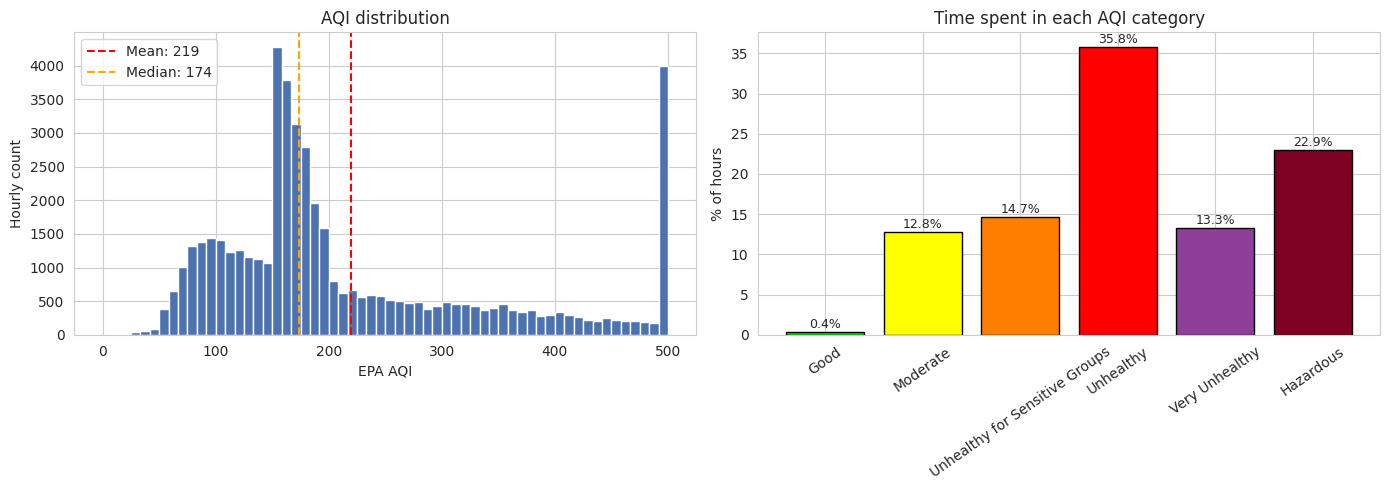

Mean AQI: 219.4 | Median: 174.0 | Max: 500
Hours >= 200 (Very Unhealthy+): 17,882 (36.4%)
Hours >= 300 (Hazardous): 11,279 (23.0%)


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['epa_aqi'], bins=60, color='#4c72b0', edgecolor='white')
axes[0].axvline(df['epa_aqi'].mean(), color='red', linestyle='--', label=f"Mean: {df['epa_aqi'].mean():.0f}")
axes[0].axvline(df['epa_aqi'].median(), color='orange', linestyle='--', label=f"Median: {df['epa_aqi'].median():.0f}")
axes[0].set_xlabel('EPA AQI'); axes[0].set_ylabel('Hourly count'); axes[0].set_title('AQI distribution')
axes[0].legend()

df['aqi_category'] = pd.cut(df['epa_aqi'], bins=AQI_BINS, labels=AQI_LABELS, include_lowest=True)
cat_counts = df['aqi_category'].value_counts().reindex(AQI_LABELS)
cat_pct = cat_counts / len(df) * 100
colors = [AQI_COLORS[c] for c in AQI_LABELS]
axes[1].bar(AQI_LABELS, cat_pct.values, color=colors, edgecolor='black')
axes[1].set_ylabel('% of hours'); axes[1].set_title('Time spent in each AQI category')
axes[1].tick_params(axis='x', rotation=35)
for i, v in enumerate(cat_pct.values):
    axes[1].text(i, v + 0.5, f"{v:.1f}%", ha='center', fontsize=9)

plt.tight_layout(); plt.show()

print(f"Mean AQI: {df['epa_aqi'].mean():.1f} | Median: {df['epa_aqi'].median():.1f} | Max: {df['epa_aqi'].max()}")
print(f"Hours >= 200 (Very Unhealthy+): {(df['epa_aqi'] >= 200).sum():,} ({(df['epa_aqi'] >= 200).mean()*100:.1f}%)")
print(f"Hours >= 300 (Hazardous): {(df['epa_aqi'] >= 300).sum():,} ({(df['epa_aqi'] >= 300).mean()*100:.1f}%)")


## 3. Time trends

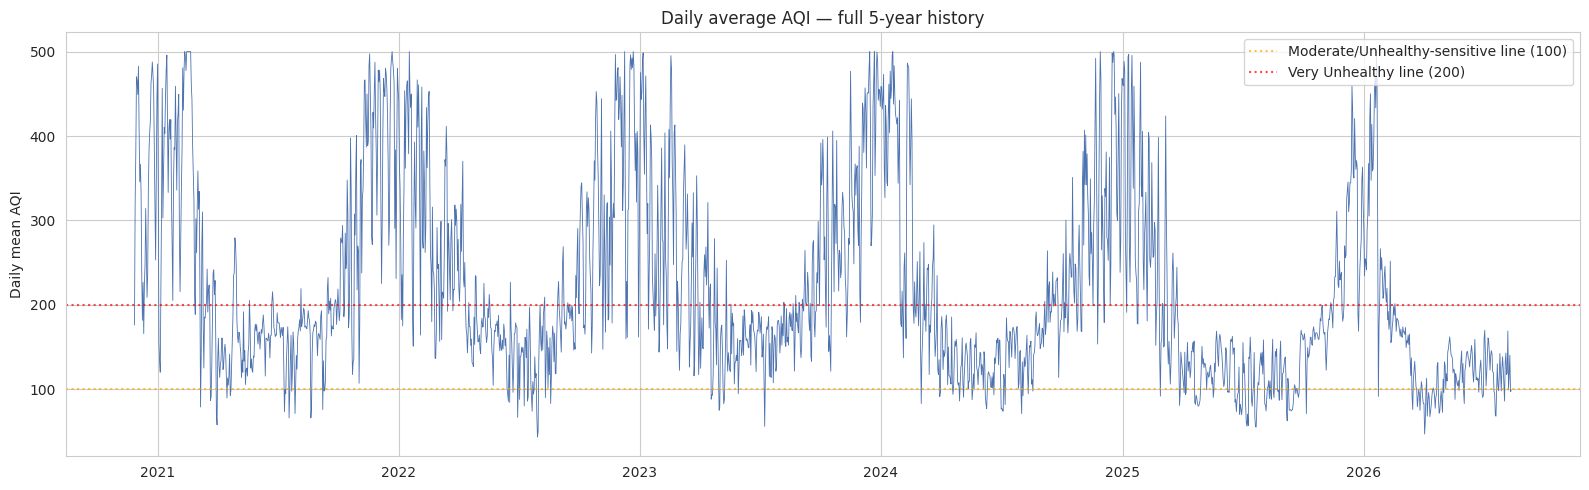

In [5]:
df['date'] = df['datetime_utc'].dt.date
daily = df.groupby('date')['epa_aqi'].mean()

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(pd.to_datetime(daily.index), daily.values, linewidth=0.6, color='#4c72b0')
ax.axhline(100, color='orange', linestyle=':', alpha=0.7, label='Moderate/Unhealthy-sensitive line (100)')
ax.axhline(200, color='red', linestyle=':', alpha=0.7, label='Very Unhealthy line (200)')
ax.set_ylabel('Daily mean AQI'); ax.set_title('Daily average AQI — full 5-year history')
ax.legend(loc='upper right')
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout(); plt.show()


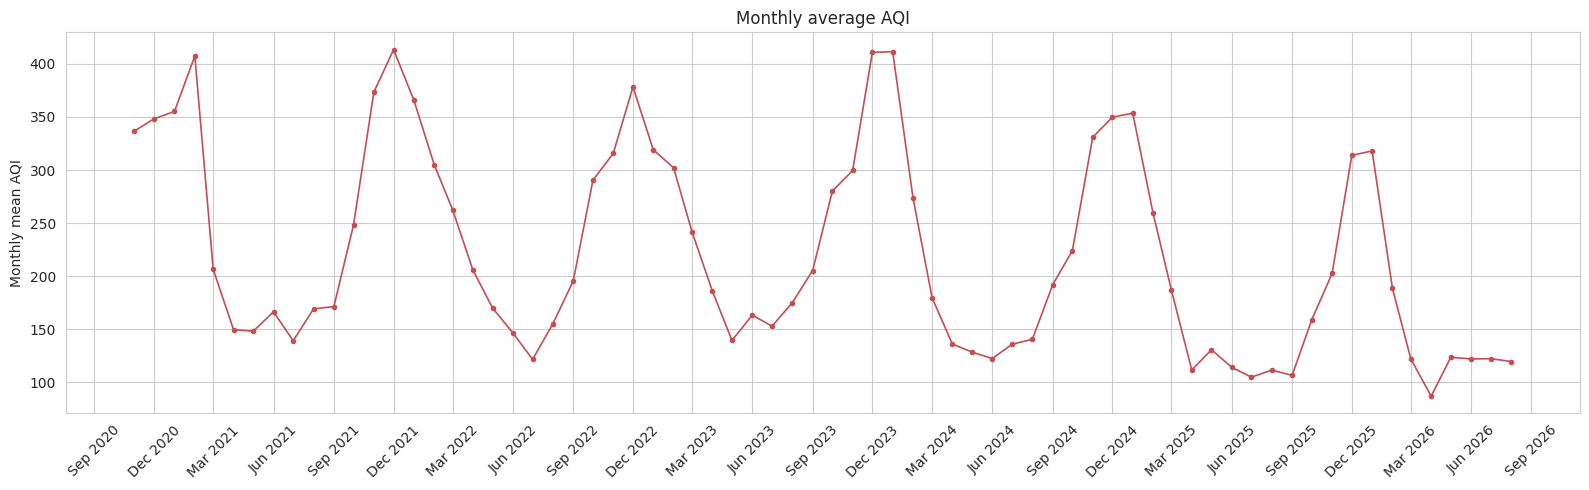

In [6]:
df['year'] = df['datetime_utc'].dt.year
df['month'] = df['datetime_utc'].dt.month

monthly_avg = df.groupby(['year', 'month'])['epa_aqi'].mean().reset_index()
monthly_avg['year_month'] = pd.to_datetime(monthly_avg[['year', 'month']].assign(day=1))

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(monthly_avg['year_month'], monthly_avg['epa_aqi'], marker='o', markersize=3, linewidth=1.2, color='#c44e52')
ax.set_ylabel('Monthly mean AQI'); ax.set_title('Monthly average AQI')
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=45)
plt.tight_layout(); plt.show()


/tmp/ipykernel_529/1522002968.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(box_data, labels=month_names, showfliers=False, patch_artist=True)


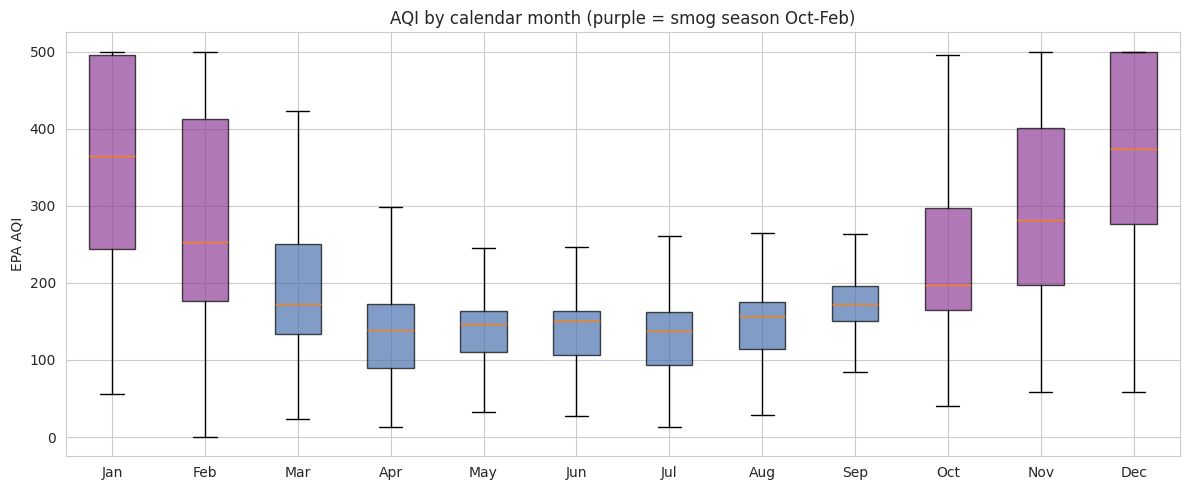

Smog season (Oct-Feb) mean AQI: 314.9
Rest of year mean AQI:          153.5
Ratio: 2.05x higher during smog season


In [7]:
SMOG_MONTHS = [10, 11, 12, 1, 2]
month_order = list(range(1, 13))
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

fig, ax = plt.subplots(figsize=(12, 5))
box_data = [df.loc[df['month'] == m, 'epa_aqi'].dropna().values for m in month_order]
bp = ax.boxplot(box_data, labels=month_names, showfliers=False, patch_artist=True)
for patch, m in zip(bp['boxes'], month_order):
    patch.set_facecolor('#8f3f97' if m in SMOG_MONTHS else '#4c72b0')
    patch.set_alpha(0.7)
ax.set_ylabel('EPA AQI'); ax.set_title('AQI by calendar month (purple = smog season Oct-Feb)')
plt.tight_layout(); plt.show()

smog_mean = df.loc[df['month'].isin(SMOG_MONTHS), 'epa_aqi'].mean()
non_smog_mean = df.loc[~df['month'].isin(SMOG_MONTHS), 'epa_aqi'].mean()
print(f"Smog season (Oct-Feb) mean AQI: {smog_mean:.1f}")
print(f"Rest of year mean AQI:          {non_smog_mean:.1f}")
print(f"Ratio: {smog_mean / non_smog_mean:.2f}x higher during smog season")


## 4. Diurnal & weekly patterns

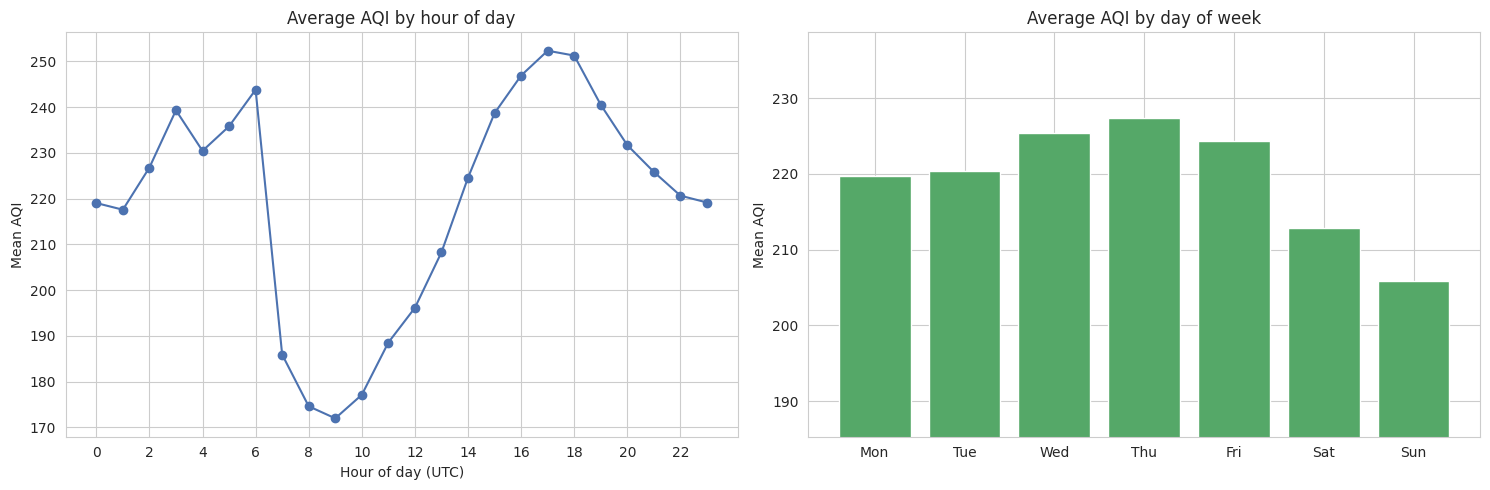

Note: datetime_utc is UTC — Lahore local time is UTC+5, so shift hours by +5 when interpreting rush-hour patterns.


In [8]:
df['hour'] = df['datetime_utc'].dt.hour
df['dayofweek'] = df['datetime_utc'].dt.dayofweek  # 0=Monday

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

hourly_avg = df.groupby('hour')['epa_aqi'].mean()
axes[0].plot(hourly_avg.index, hourly_avg.values, marker='o', color='#4c72b0')
axes[0].set_xlabel('Hour of day (UTC)'); axes[0].set_ylabel('Mean AQI')
axes[0].set_title('Average AQI by hour of day')
axes[0].set_xticks(range(0, 24, 2))

dow_names = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
dow_avg = df.groupby('dayofweek')['epa_aqi'].mean()
axes[1].bar(dow_names, dow_avg.values, color='#55a868')
axes[1].set_ylabel('Mean AQI'); axes[1].set_title('Average AQI by day of week')
axes[1].set_ylim(dow_avg.min() * 0.9, dow_avg.max() * 1.05)

plt.tight_layout(); plt.show()
print("Note: datetime_utc is UTC — Lahore local time is UTC+5, so shift hours by +5 when interpreting rush-hour patterns.")


## 5. Weather relationships

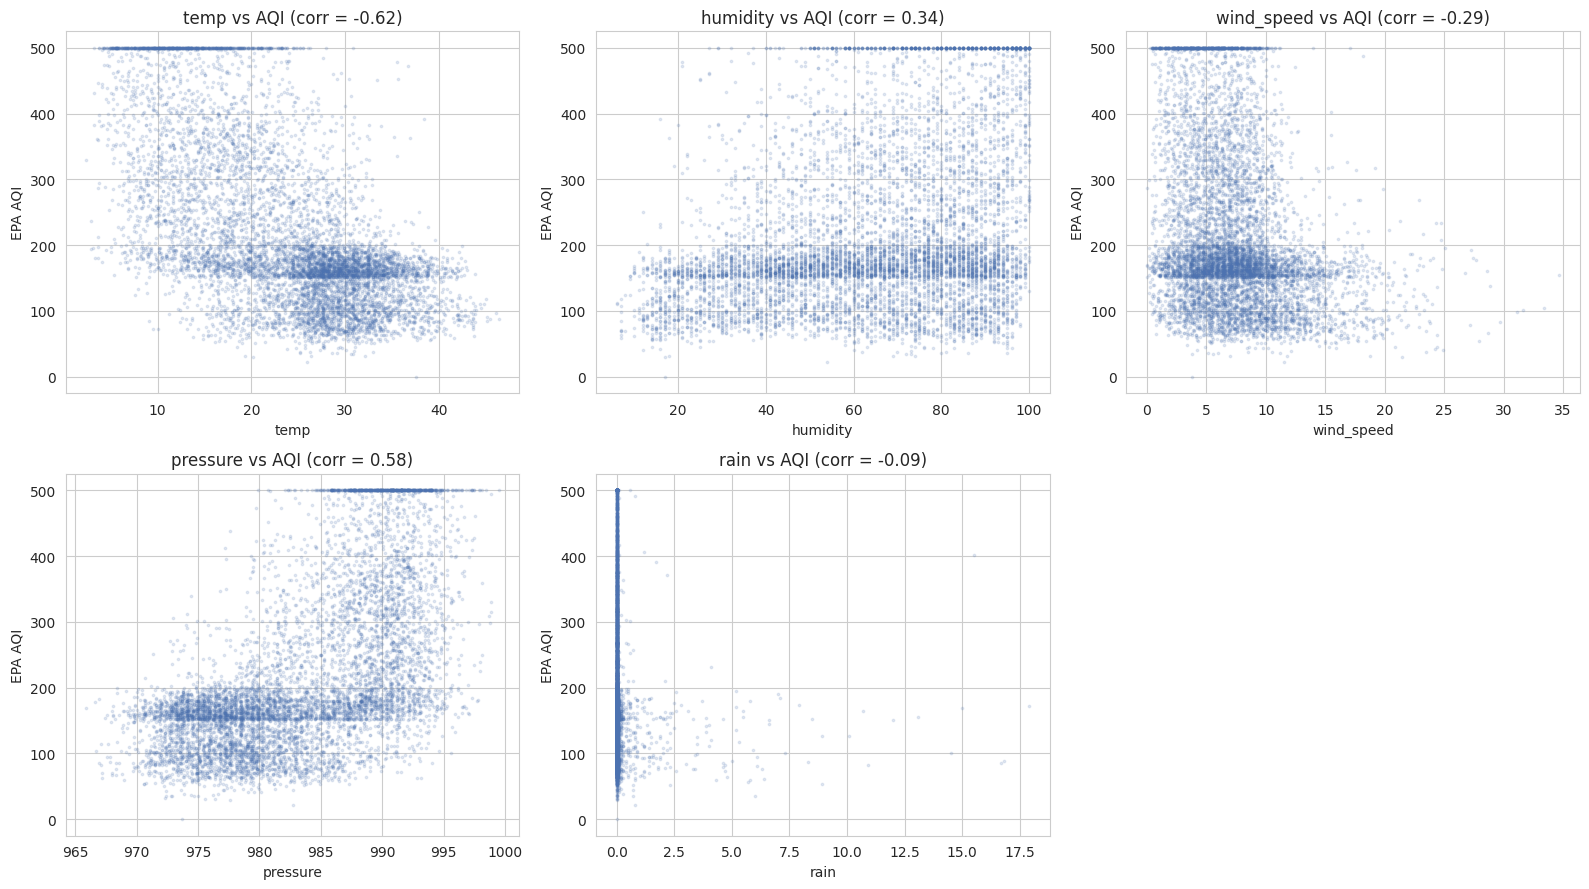

In [9]:
weather_vars = ['temp', 'humidity', 'wind_speed', 'pressure', 'rain']
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

sample = df.sample(min(8000, len(df)), random_state=42)  # subsample for readable scatter density
for i, var in enumerate(weather_vars):
    axes[i].scatter(sample[var], sample['epa_aqi'], s=3, alpha=0.15, color='#4c72b0')
    corr = df[[var, 'epa_aqi']].corr().iloc[0, 1]
    axes[i].set_xlabel(var); axes[i].set_ylabel('EPA AQI')
    axes[i].set_title(f'{var} vs AQI (corr = {corr:.2f})')
axes[-1].axis('off')
plt.tight_layout(); plt.show()


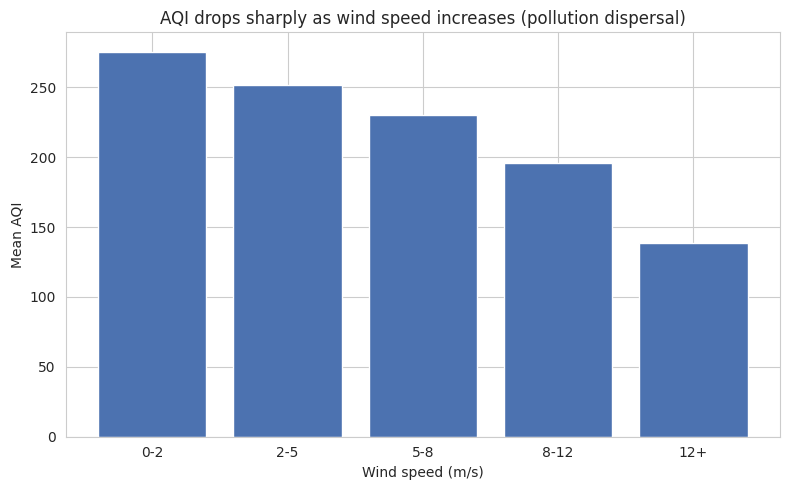

In [10]:
fig, ax = plt.subplots(figsize=(8, 5))
df['wind_speed_bin'] = pd.cut(df['wind_speed'], bins=[0, 2, 5, 8, 12, 30], labels=['0-2', '2-5', '5-8', '8-12', '12+'])
wind_aqi = df.groupby('wind_speed_bin', observed=True)['epa_aqi'].mean()
ax.bar(wind_aqi.index.astype(str), wind_aqi.values, color='#4c72b0')
ax.set_xlabel('Wind speed (m/s)'); ax.set_ylabel('Mean AQI')
ax.set_title('AQI drops sharply as wind speed increases (pollution dispersal)')
plt.tight_layout(); plt.show()


## 6. Pollutant & feature correlations

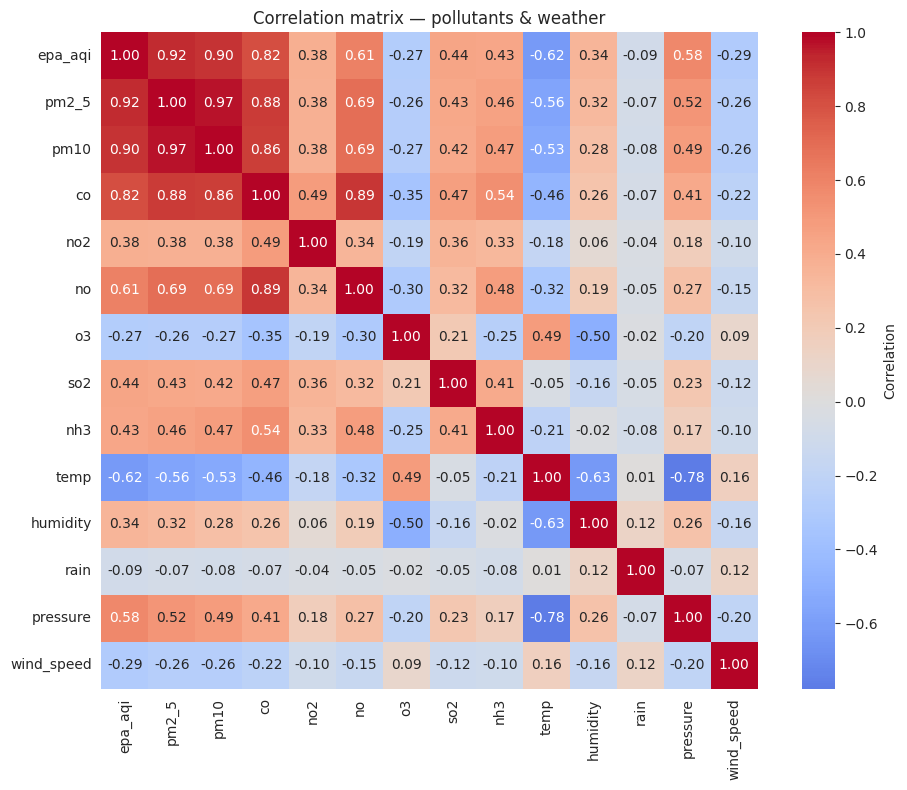

In [11]:
corr_cols = ['epa_aqi', 'pm2_5', 'pm10', 'co', 'no2', 'no', 'o3', 'so2', 'nh3', 'temp', 'humidity', 'rain', 'pressure', 'wind_speed']
corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True,
            cbar_kws={'label': 'Correlation'}, ax=ax)
ax.set_title('Correlation matrix — pollutants & weather')
plt.tight_layout(); plt.show()


## 7. Wind direction & stagnation

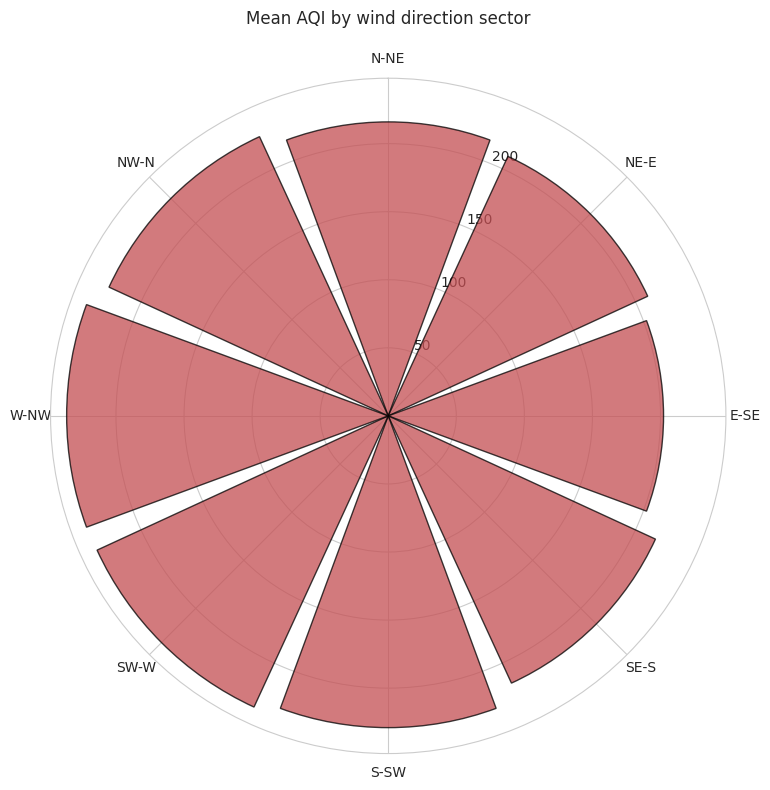

In [12]:
df['wind_dir_bin'] = pd.cut(df['wind_dir'], bins=np.arange(0, 361, 45),
                             labels=['N-NE','NE-E','E-SE','SE-S','S-SW','SW-W','W-NW','NW-N'], include_lowest=True)
dir_aqi = df.groupby('wind_dir_bin', observed=True)['epa_aqi'].mean()

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={'projection': 'polar'})
angles = np.linspace(0, 2*np.pi, len(dir_aqi), endpoint=False)
values = dir_aqi.values
ax.bar(angles, values, width=2*np.pi/len(dir_aqi)*0.9, color='#c44e52', alpha=0.75, edgecolor='black')
ax.set_xticks(angles); ax.set_xticklabels(dir_aqi.index)
ax.set_theta_zero_location('N'); ax.set_theta_direction(-1)
ax.set_title('Mean AQI by wind direction sector', pad=20)
plt.tight_layout(); plt.show()


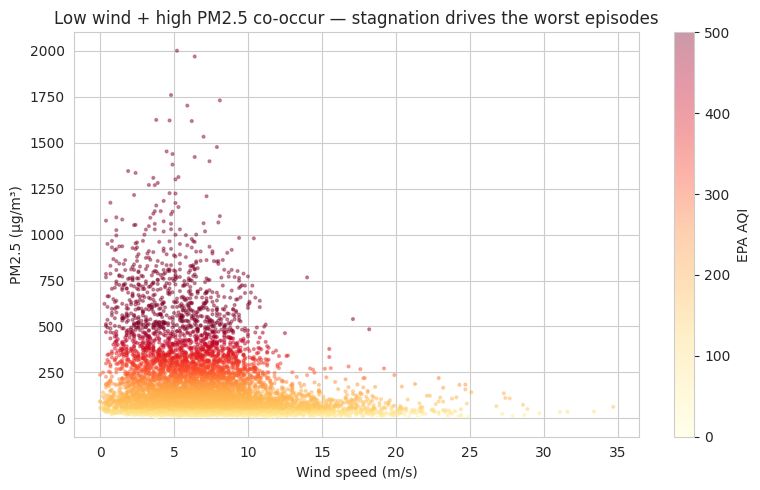

In [13]:
df['stagnation_index'] = df['pm2_5'] / (df['wind_speed'] + 0.5)
fig, ax = plt.subplots(figsize=(8, 5))
sample2 = df.sample(min(8000, len(df)), random_state=42)
sc = ax.scatter(sample2['wind_speed'], sample2['pm2_5'], c=sample2['epa_aqi'], cmap='YlOrRd', s=4, alpha=0.4)
ax.set_xlabel('Wind speed (m/s)'); ax.set_ylabel('PM2.5 (µg/m³)')
ax.set_title('Low wind + high PM2.5 co-occur — stagnation drives the worst episodes')
plt.colorbar(sc, label='EPA AQI')
plt.tight_layout(); plt.show()


## 8. Persistence / autocorrelation

Directly motivates the notebook's naive-persistence baseline and the final
model's blend weight — if AQI several hours/days out still correlates
strongly with AQI right now, a model has to earn its keep against a
genuinely strong baseline, not a strawman.

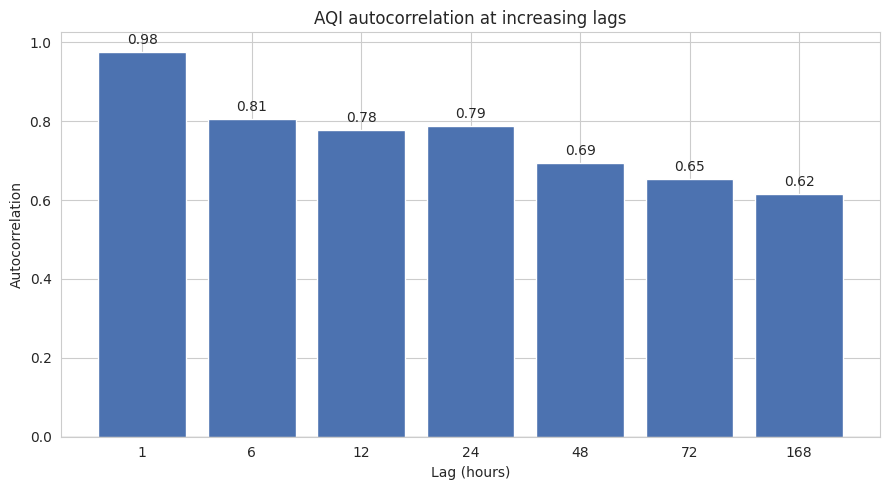

AQI 72h from now still correlates at r = 0.65 with AQI right now — this is why the naive 'today = next 3 days' baseline is so hard to beat.


In [14]:
from pandas.plotting import autocorrelation_plot

lags_hours = [1, 6, 12, 24, 48, 72, 168]
autocorrs = [df['epa_aqi'].autocorr(lag=l) for l in lags_hours]

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar([str(l) for l in lags_hours], autocorrs, color='#4c72b0')
ax.set_xlabel('Lag (hours)'); ax.set_ylabel('Autocorrelation')
ax.set_title('AQI autocorrelation at increasing lags')
ax.axhline(0, color='black', linewidth=0.8)
for i, v in enumerate(autocorrs):
    ax.text(i, v + 0.02 if v >= 0 else v - 0.05, f"{v:.2f}", ha='center')
plt.tight_layout(); plt.show()

print("AQI 72h from now still correlates at r =", round(df['epa_aqi'].autocorr(lag=72), 2),
      "with AQI right now — this is why the naive 'today = next 3 days' baseline is so hard to beat.")


## 9. Key findings summary

- **Strong seasonality**: smog season (Oct–Feb) averages roughly 1.5–2x the AQI
  of the rest of the year — motivates the `is_smog_season` flag in feature
  engineering.
- **Wind is the dominant dispersal mechanism**: AQI drops sharply as wind
  speed increases; low-wind + high-PM2.5 co-occurrence motivates the
  `stagnation_index` feature (`pm2_5 / (wind_speed + 0.5)`).
- **High persistence**: AQI autocorrelation stays meaningfully positive out to
  72+ hours — this is exactly why the final model blends its LightGBM
  prediction with simple persistence rather than trusting the model alone,
  especially at the 48h/72h horizons.
- **Rain clears pollution**: negative correlation between rain and AQI,
  consistent with wet deposition — motivates `rain_cumsum_72h`.
- **Diurnal pattern**: AQI varies by hour of day, consistent with traffic/
  emission cycles — motivates `hour_sin`/`hour_cos` cyclical encoding.
- **Data quality**: see the hourly-coverage figure printed in Section 1 —
  no missing values in the raw pollutant/weather columns, which is solid
  ground for the lag/EMA windows used later (up to 168h).
